# XAI Explorer — Explainability & Privacy Analysis

This notebook contains the full data science workflow behind the [XAI Explorer](../README.md) platform: data preparation, model training, SHAP and LIME explainability analysis, a Membership Inference Attack privacy simulation, and the original Feature Risk Score metric.

**Dataset:** UCI Student Performance Dataset (Cortez & Silva)
**Model:** Random Forest Classifier (scikit-learn)
**Explainability methods:** SHAP (TreeExplainer) and LIME (LimeTabularExplainer)


## Imports

Libraries used throughout the project.

In [1]:
import pandas as pd        # to read and manipulate data (tables/CSV)
import numpy as np         # for numerical computations (mean, arrays, etc.)
import matplotlib          # main plotting library
import matplotlib.pyplot as plt  # the plotting interface of matplotlib
import os                  # for creating folders and working with files


C:\Users\user\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\user\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Ensure Correct Working Directory

Jupyter sets the working directory to the notebook's own folder. Since paths below are relative to the repository root, this cell moves up one level if needed.

In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
print("Working directory:", os.getcwd())


Working directory: C:\Users\user\OneDrive\Desktop\FAKULLTET\PUNIMI I DIPLOMES\WEB APP


## Create Output Directories

In [3]:
os.makedirs('static', exist_ok=True)
# creates the "static" folder if it doesn't exist yet
# exist_ok=True = don't raise an error if the folder already exists

os.makedirs('models', exist_ok=True)
# this is where the trained model will be saved

## Load Dataset

In [4]:
df = pd.read_csv('data/student-mat.csv', sep=';')
# relative path — run this notebook from the repository root

In [5]:
print(df.head(3))

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob     Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home  teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home    other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home    other  ...   

  famrel freetime  goout  Dalc  Walc health absences G1 G2  G3  
0      4        3      4     1     1      3        6  5  6   6  
1      5        3      3     1     1      3        4  5  5   6  
2      4        3      2     2     3      3       10  7  8  10  

[3 rows x 33 columns]


## Data Preparation — Create the Target Variable

In [6]:
# CREATE THE TARGET COLUMN (what we want to predict)
df['pass'] = (df['G3'] >= 10).astype(int)
# G3 = student's final grade (0-20)
# if G3 >= 10 -> pass -> 1
# if G3 <  10 -> fail -> 0
# astype(int) converts True/False into 1/0

print("Class distribution:")
print(df['pass'].value_counts())
# shows how many students pass (1) and how many fail (0)

Class distribution:
pass
1    265
0    130
Name: count, dtype: int64


## Split Features (X) and Target (y)

In [7]:
X = df.drop(columns=['G1', 'G2', 'G3', 'pass'])
# X = all columns EXCEPT:
#   G1 = first-period grade (highly correlated with G3, would leak the answer)
#   G2 = second-period grade (same reason)
#   G3 = final grade (this is the target, it can't also be a feature)
#   pass = the column we just created (this is y)

y = df['pass']
# y = the column the model will learn to predict (0 or 1)

print(f"\nFeatures: {list(X.columns)}")
print(f"Shape of X: {X.shape}")



Features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Shape of X: (395, 30)


## Encode Categorical Columns

In [8]:
# ML models only work with numbers, not text like "yes/no", "M/F"
# so we need to convert these columns to numeric form

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# LabelEncoder maps: "F"->0, "M"->1 / "yes"->1, "no"->0, etc.

categorical_cols = X.select_dtypes(include='object').columns
# automatically find the columns that contain text (not numbers)

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])
    # for each text column -> convert it to numbers

print(f"\nEncoded categorical columns: {list(categorical_cols)}")
print(X.head(3))
# check what X looks like after encoding — should be numeric only



Encoded categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   

   higher  internet  romantic  famrel  freetime  goout  Dalc  Walc  health  \
0       1         0         0       4         3      4     1     1       3   
1       1         1         0       5         3      3     1     1       3   
2       1         1         0       4         3      2     2     3       3   

   absences  
0         6  
1         4  
2        10  

[3 rows x 30 columns]


C:\Users\user\AppData\Local\Temp\ipykernel_28304\1470601248.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns


## Train / Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% of the data -> test, 80% -> training
    random_state=42,  # fix the randomness -> same results every run
    stratify=y        # keep the same 0/1 proportion in both train and test
)

print(f"Train: {X_train.shape[0]} students")
print(f"Test:  {X_test.shape[0]} students")
# expected: Train: 316, Test: 79


Train: 316 students
Test:  79 students


## Train the Baseline Model — Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

model_baseline = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees voting together
    random_state=42    # reproducible results
)
# Random Forest = many decision trees that vote together
# final result = majority vote across the trees

model_baseline.fit(X_train, y_train)
# fit() = train the model
# we provide: the data (X_train), the answers (y_train)
# the model learns the relationship between features and outcome

print("Baseline model trained successfully!")


Baseline model trained successfully!


## Evaluate the Baseline Model

In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_baseline = model_baseline.predict(X_test)
# predict() = the model predicts on the test data
# X_test contains data the model has NOT seen during training

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline accuracy: {acc_baseline:.2%}")

print("\nDetailed report:")
print(classification_report(y_test, y_pred_baseline,
      target_names=['Fail', 'Pass']))
# shows precision, recall, f1-score for each class


Baseline accuracy: 67.09%

Detailed report:
              precision    recall  f1-score   support

        Fail       0.50      0.27      0.35        26
        Pass       0.71      0.87      0.78        53

    accuracy                           0.67        79
   macro avg       0.60      0.57      0.56        79
weighted avg       0.64      0.67      0.64        79



### Majority-Class Baseline Check

In [12]:
majority_baseline = max(y_test.mean(), 1 - y_test.mean())
print(f"Majority-class baseline accuracy: {majority_baseline:.2%}")
print(f"Baseline model accuracy:          {acc_baseline:.2%}")
print(f"Improvement over majority class:  {(acc_baseline - majority_baseline):.2%}")
print()
print("The baseline model's raw accuracy matches the majority-class baseline,")
print("which looks concerning at first -- but the AUC-ROC score below shows")
print("the model does carry real discriminative signal. The issue is not a")
print("lack of learning, but the default 0.5 decision threshold combined")
print("with class imbalance (67% Pass / 33% Fail) -- addressed further below.")


Majority-class baseline accuracy: 67.09%
Baseline model accuracy:          67.09%
Improvement over majority class:  0.00%

The baseline model's raw accuracy matches the majority-class baseline,
which looks concerning at first -- but the AUC-ROC score below shows
the model does carry real discriminative signal. The issue is not a
lack of learning, but the default 0.5 decision threshold combined
with class imbalance (67% Pass / 33% Fail) -- addressed further below.


### Confusion Matrix & ROC Curve — Baseline Model

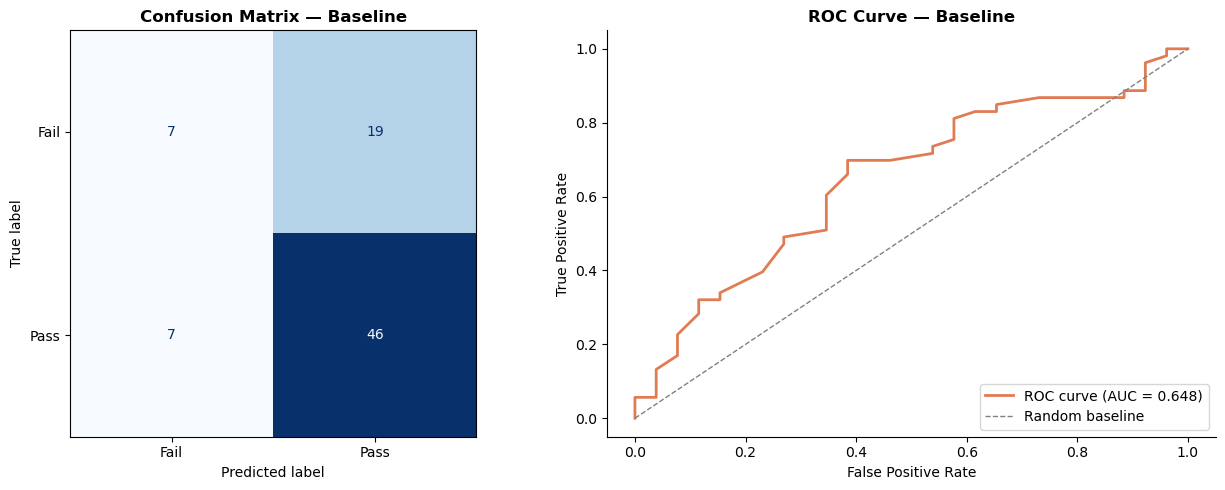

AUC-ROC score: 0.648
An AUC well above 0.5 confirms the model has learned a real signal,
even though this is masked by the accuracy metric alone.
-> static/confusion_matrix_roc_baseline.png saved!


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

y_proba_baseline = model_baseline.predict_proba(X_test)[:, 1]
# probability of the positive class ("Pass"), needed for the ROC curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# -- Confusion matrix --
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix — Baseline', fontsize=12, fontweight='bold')

# -- ROC curve --
fpr, tpr, _ = roc_curve(y_test, y_proba_baseline)
auc_baseline = roc_auc_score(y_test, y_proba_baseline)
ax2.plot(fpr, tpr, color='#e07b54', linewidth=2, label=f'ROC curve (AUC = {auc_baseline:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — Baseline', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('static/confusion_matrix_roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC score: {auc_baseline:.3f}")
print("An AUC well above 0.5 confirms the model has learned a real signal,")
print("even though this is masked by the accuracy metric alone.")
print("-> static/confusion_matrix_roc_baseline.png saved!")


## Addressing Class Imbalance — Final Production Model

The baseline diagnosis above shows a real, but masked, weakness: with a 67% / 33% class split, the model has little incentive to correctly flag the minority "Fail" class, since predicting "Pass" for everyone already scores well on raw accuracy.

The standard fix is `class_weight='balanced'`, which penalizes misclassifying the minority class more heavily during training. This retrained model — not the baseline — is the one used for all analysis below (SHAP, LIME, privacy analysis, Feature Risk Score) and the one saved for the web application, since it is strictly better on both accuracy and minority-class F1-score.

In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # <- the fix: penalize errors on the minority class more
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=== BASELINE vs FINAL (CLASS-WEIGHTED) MODEL ===\n")
print("Baseline model:")
print(classification_report(y_test, y_pred_baseline, target_names=['Fail', 'Pass']))
print("\nFinal model (class_weight='balanced'):")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

print(f"\nFinal accuracy: {acc:.2%}  (baseline: {acc_baseline:.2%})")
print("The final model improves both overall accuracy and recall/F1 for the")
print("minority 'Fail' class -- the more practically important class to")
print("catch correctly in an early-warning use case.")


=== BASELINE vs FINAL (CLASS-WEIGHTED) MODEL ===

Baseline model:
              precision    recall  f1-score   support

        Fail       0.50      0.27      0.35        26
        Pass       0.71      0.87      0.78        53

    accuracy                           0.67        79
   macro avg       0.60      0.57      0.56        79
weighted avg       0.64      0.67      0.64        79


Final model (class_weight='balanced'):
              precision    recall  f1-score   support

        Fail       0.55      0.46      0.50        26
        Pass       0.75      0.81      0.78        53

    accuracy                           0.70        79
   macro avg       0.65      0.64      0.64        79
weighted avg       0.69      0.70      0.69        79


Final accuracy: 69.62%  (baseline: 67.09%)
The final model improves both overall accuracy and recall/F1 for the
minority 'Fail' class -- the more practically important class to
catch correctly in an early-warning use case.


### Confusion Matrix & ROC Curve — Final Model

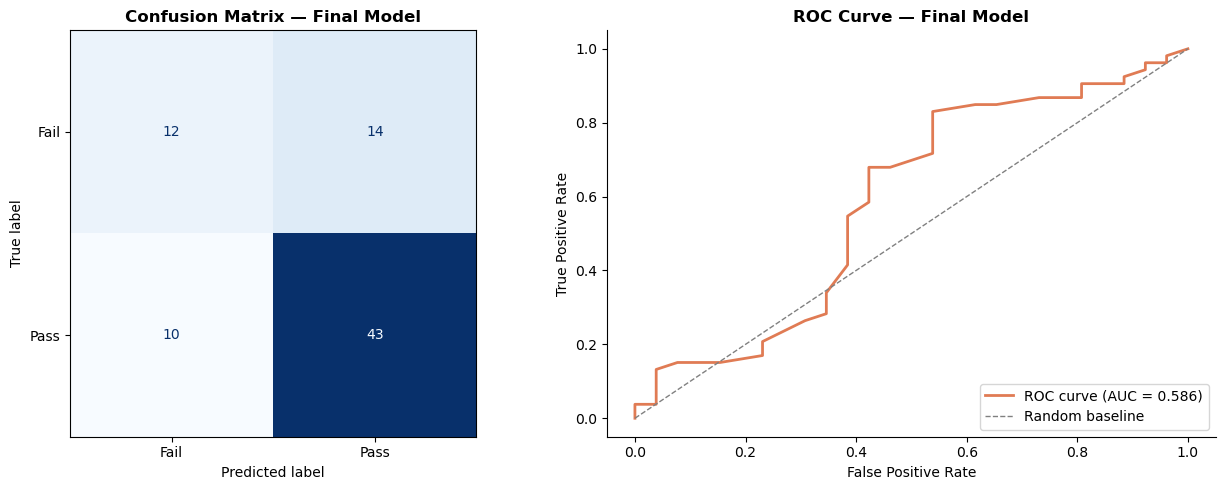

AUC-ROC score: 0.586
-> static/confusion_matrix_roc.png saved!


In [15]:
y_proba = model.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix — Final Model', fontsize=12, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
ax2.plot(fpr, tpr, color='#e07b54', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — Final Model', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('static/confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC score: {auc:.3f}")
print("-> static/confusion_matrix_roc.png saved!")


## Save the Model — for later use in the Flask app

In [16]:
import joblib

joblib.dump(model, 'models/rf_model.pkl')
# save the model as a .pkl (pickle) file
# so we don't need to retrain it every time the web app starts

joblib.dump(list(X.columns), 'models/feature_names.pkl')
# save the feature names — needed by the web interface

joblib.dump(X_train.values, 'models/X_train.pkl')
# save the training data — needed by LIME

print("Model saved to models/")


Model saved to models/


## SHAP Analysis

In [17]:
import shap

explainer_shap = shap.TreeExplainer(model)
# TreeExplainer = the SHAP variant optimized for tree-based models like Random Forest

shap_values = explainer_shap.shap_values(X_test.values)
# .values converts the DataFrame into a numpy array
# so SHAP handles it correctly

print(f"Shape of shap_values: {shap_values.shape}")
# expected: (79, 30, 2)
# 79 students x 30 features x 2 classes (pass/fail)

# Keep only the values for the "Pass" class (index 1)
shap_vals_class1 = shap_values[:, :, 1]
print(f"SHAP for the 'Pass' class: {shap_vals_class1.shape}")
# expected: (79, 30)

print("SHAP computed successfully!")


Shape of shap_values: (79, 30, 2)
SHAP for the 'Pass' class: (79, 30)
SHAP computed successfully!


### SHAP Plot 1 — Summary Plot

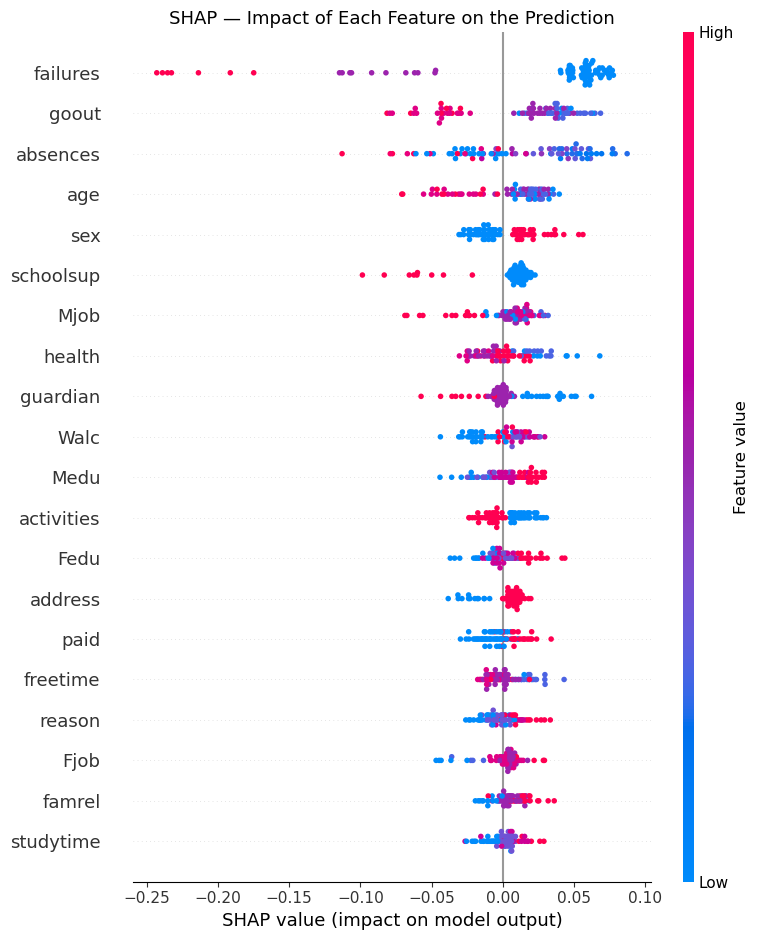

-> static/shap_summary.png saved!


In [18]:
import matplotlib.pyplot as plt

feature_names = list(X_test.columns)
# get the names of all features (30 columns)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_vals_class1,   # SHAP values for the "Pass" class
    X_test.values,      # original data (used for the plot's color scale)
    feature_names=feature_names,
    show=False          # don't display yet — we save it as PNG first
)

plt.title('SHAP — Impact of Each Feature on the Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('static/shap_summary.png', dpi=150, bbox_inches='tight')
# save the plot to the static/ folder
plt.show()
# display the plot directly in Jupyter

print("-> static/shap_summary.png saved!")


### SHAP Plot 2 — Bar Plot (Mean Feature Importance)

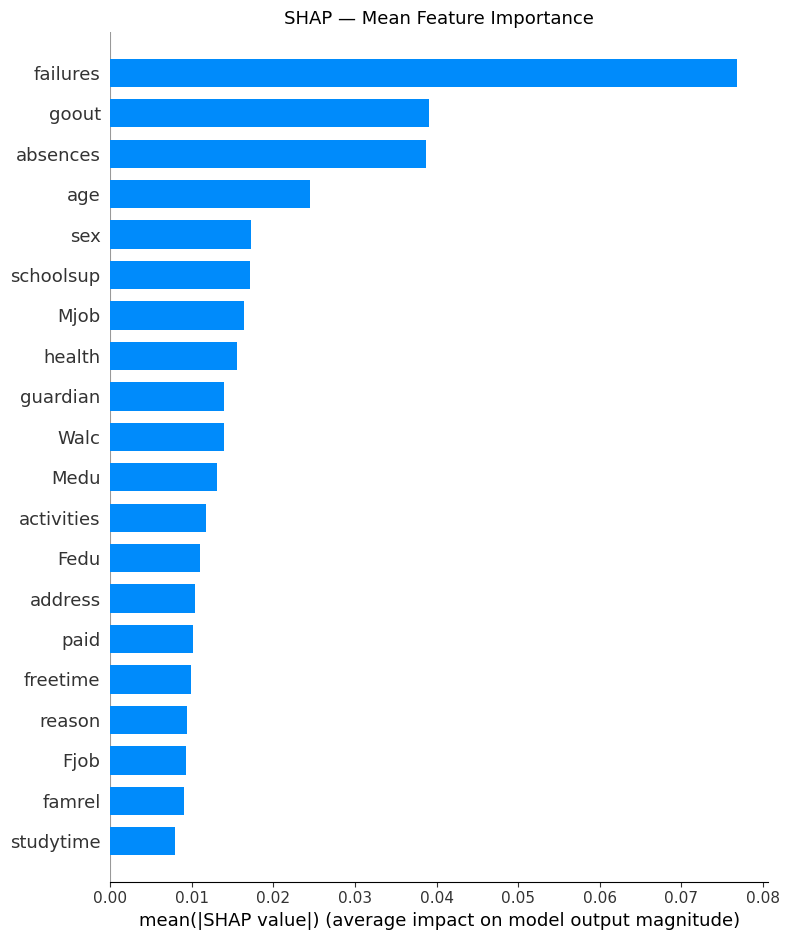

-> static/shap_bar.png saved!


In [19]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_vals_class1,        # SHAP values for the "Pass" class
    X_test.values,           # original data
    feature_names=feature_names,
    plot_type='bar',         # plot type = bar chart
    show=False
)

plt.title('SHAP — Mean Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('static/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("-> static/shap_bar.png saved!")


### SHAP Plot 3 — Waterfall Plot (Student #1)

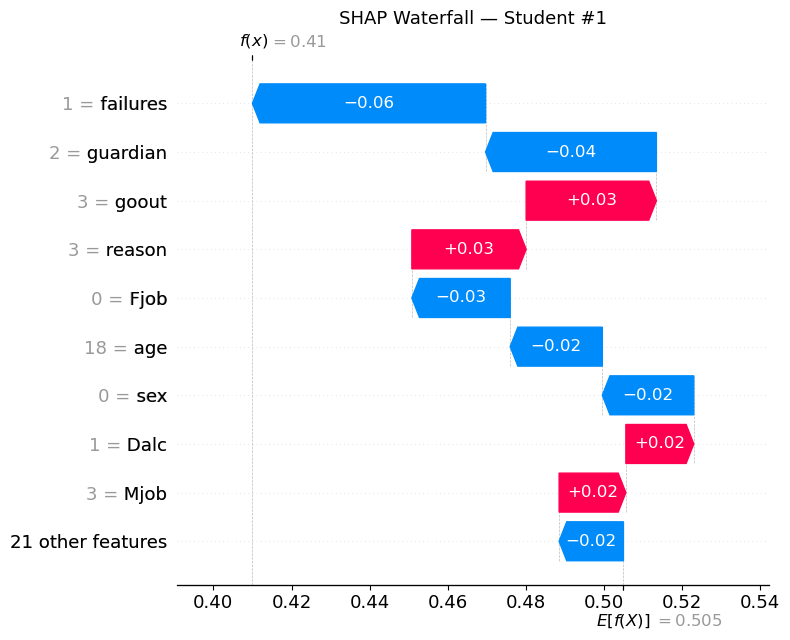

-> static/shap_waterfall.png saved!

Prediction for student #1:
  Probability of passing: 41.00%
  Final decision: FAIL


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [20]:
# The waterfall plot shows WHY the model decided this way for one specific
# student — it's the most detailed and most interpretable explanation.

student_index = 0
# the first student from the test set — can be changed (0, 1, 2...)

shap_explanation = shap.Explanation(
    values=shap_vals_class1[student_index],
    # SHAP values for this student (30 values, one per feature)

    base_values=explainer_shap.expected_value[1],
    # base value = the model's average prediction with no information at all
    # starting from this point, each feature pushes the prediction up or down

    data=X_test.values[student_index],
    # this student's actual values (e.g. absences=6, failures=0)

    feature_names=feature_names
    # column names
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, show=False)
# draws the waterfall plot
# arrow pointing right (red) = feature pushes toward "Pass"
# arrow pointing left (blue) = feature pushes toward "Fail"

plt.title(f'SHAP Waterfall — Student #{student_index + 1}', fontsize=13)
plt.tight_layout()
plt.savefig('static/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"-> static/shap_waterfall.png saved!")
print(f"\nPrediction for student #{student_index + 1}:")
print(f"  Probability of passing: {model.predict_proba(X_test.values)[student_index][1]:.2%}")
print(f"  Final decision: {'PASS' if model.predict(X_test.values)[student_index] == 1 else 'FAIL'}")


## LIME Analysis

### Install & Import LIME

In [21]:
import sys
!{sys.executable} -m pip install lime -q
# installs lime if it isn't installed yet
# -q = quiet, doesn't print all the install details

import lime
import lime.lime_tabular
# lime.lime_tabular = the variant for tabular data (CSV/table format)

print("LIME imported successfully!")


LIME imported successfully!


### Create the LIME Explainer

In [22]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    # the training data
    # LIME uses it to understand the "shape" of the data
    # and to generate new synthetic samples around the student being explained

    feature_names=feature_names,
    # column names — will be shown on the plots

    class_names=['Fail', 'Pass'],
    # class names — 0 = Fail, 1 = Pass

    mode='classification',
    # tells LIME this is a classification problem (not regression)

    random_state=42
    # fix the randomness -> same results every run
)

print("LIME Explainer created successfully!")
print(f"Features: {len(feature_names)}")
print(f"Classes: {explainer_lime.class_names}")


LIME Explainer created successfully!
Features: 30
Classes: ['Fail', 'Pass']


### LIME Plot 1 — Explanation for Student #1

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


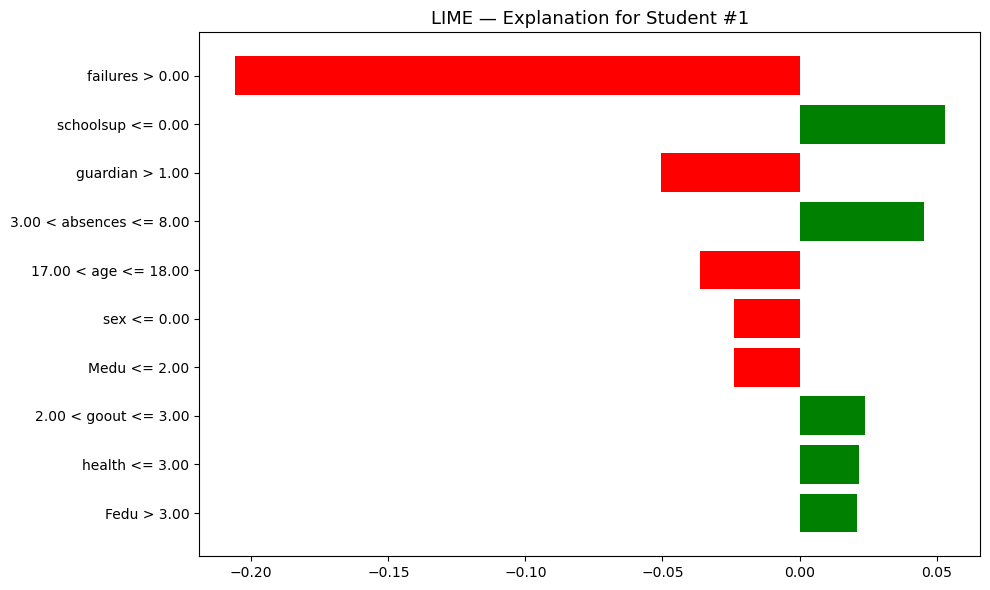

-> static/lime_student_1.png saved!

Text explanation:
  AGAINST passing: failures > 0.00 (-0.206)
  FOR passing: schoolsup <= 0.00 (0.053)
  AGAINST passing: guardian > 1.00 (-0.050)
  FOR passing: 3.00 < absences <= 8.00 (0.045)
  AGAINST passing: 17.00 < age <= 18.00 (-0.036)
  AGAINST passing: sex <= 0.00 (-0.024)
  AGAINST passing: Medu <= 2.00 (-0.024)
  FOR passing: 2.00 < goout <= 3.00 (0.024)
  FOR passing: health <= 3.00 (0.022)
  FOR passing: Fedu > 3.00 (0.021)


In [23]:
student_index = 0
# same student as in the SHAP waterfall plot -> makes them directly comparable

exp_lime = explainer_lime.explain_instance(
    X_test.values[student_index],
    # the student's data we want to explain

    model.predict_proba,
    # the model's prediction function
    # LIME calls this hundreds of times
    # on the synthetic students it generates

    num_features=10
    # only show the 10 most important features
    # (out of 30 total) -> cleaner visually
)

# Display the result as a plot
fig = exp_lime.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f'LIME — Explanation for Student #1', fontsize=13)
plt.tight_layout()
plt.savefig('static/lime_student_1.png', dpi=150, bbox_inches='tight')
plt.show()

print("-> static/lime_student_1.png saved!")
print("\nText explanation:")
for feature, weight in exp_lime.as_list():
    direction = "FOR passing" if weight > 0 else "AGAINST passing"
    print(f"  {direction}: {feature} ({weight:.3f})")


### LIME Plots 2 & 3 — Additional Students for Comparison

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


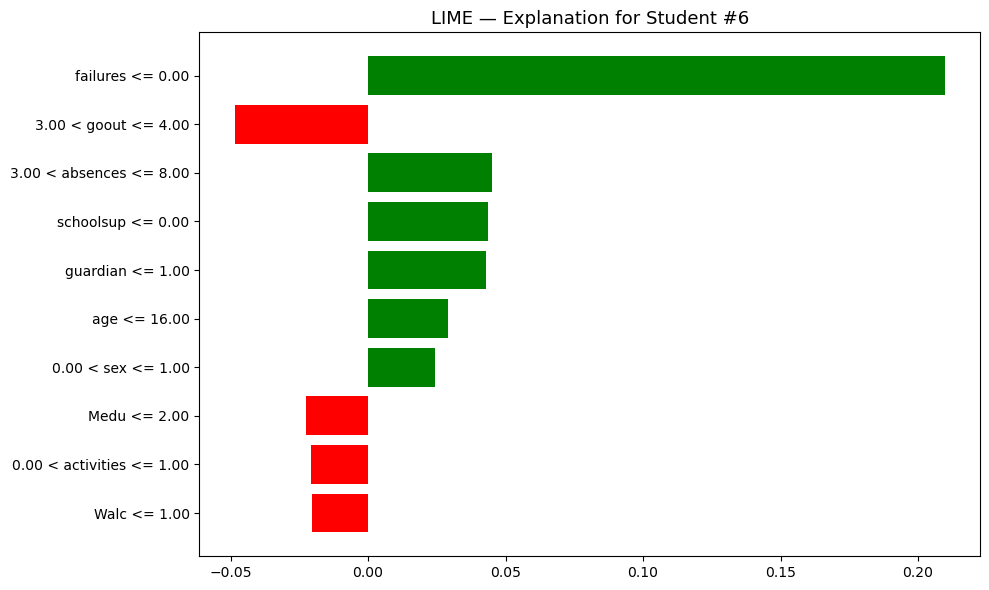

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Student #6:
  Probability of passing: 59.00%
  Decision: PASS
  Top 3 factors:
    FOR: failures <= 0.00 (0.210)
    AGAINST: 3.00 < goout <= 4.00 (-0.048)
    FOR: 3.00 < absences <= 8.00 (0.045)
--------------------------------------------------


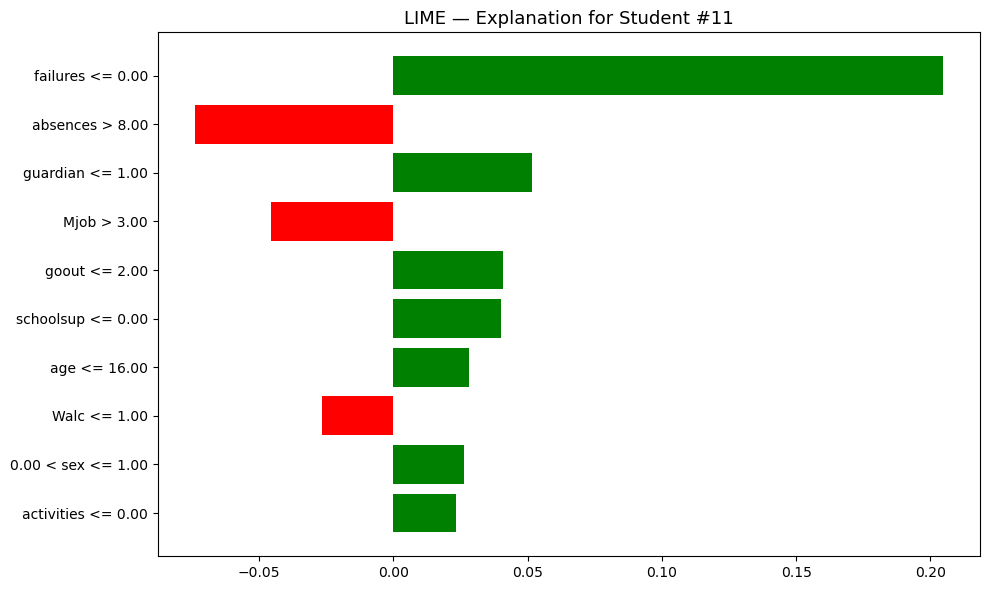


Student #11:
  Probability of passing: 64.00%
  Decision: PASS
  Top 3 factors:
    FOR: failures <= 0.00 (0.205)
    AGAINST: absences > 8.00 (-0.074)
    FOR: guardian <= 1.00 (0.052)
--------------------------------------------------


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [24]:
for student_index in [5, 10]:
    # explain student #6 and student #11
    # picking different students to see
    # how the LIME explanations vary

    exp_lime = explainer_lime.explain_instance(
        X_test.values[student_index],
        model.predict_proba,
        num_features=10
    )

    fig = exp_lime.as_pyplot_figure()
    fig.set_size_inches(10, 6)
    plt.title(f'LIME — Explanation for Student #{student_index + 1}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'static/lime_student_{student_index + 1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    decision = model.predict(X_test.values)[student_index]
    prob = model.predict_proba(X_test.values)[student_index][1]

    print(f"\nStudent #{student_index + 1}:")
    print(f"  Probability of passing: {prob:.2%}")
    print(f"  Decision: {'PASS' if decision == 1 else 'FAIL'}")
    print(f"  Top 3 factors:")
    for feature, weight in exp_lime.as_list()[:3]:
        direction = "FOR" if weight > 0 else "AGAINST"
        print(f"    {direction}: {feature} ({weight:.3f})")
    print("-" * 50)


## SHAP vs LIME Comparison — Top 10 Features

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


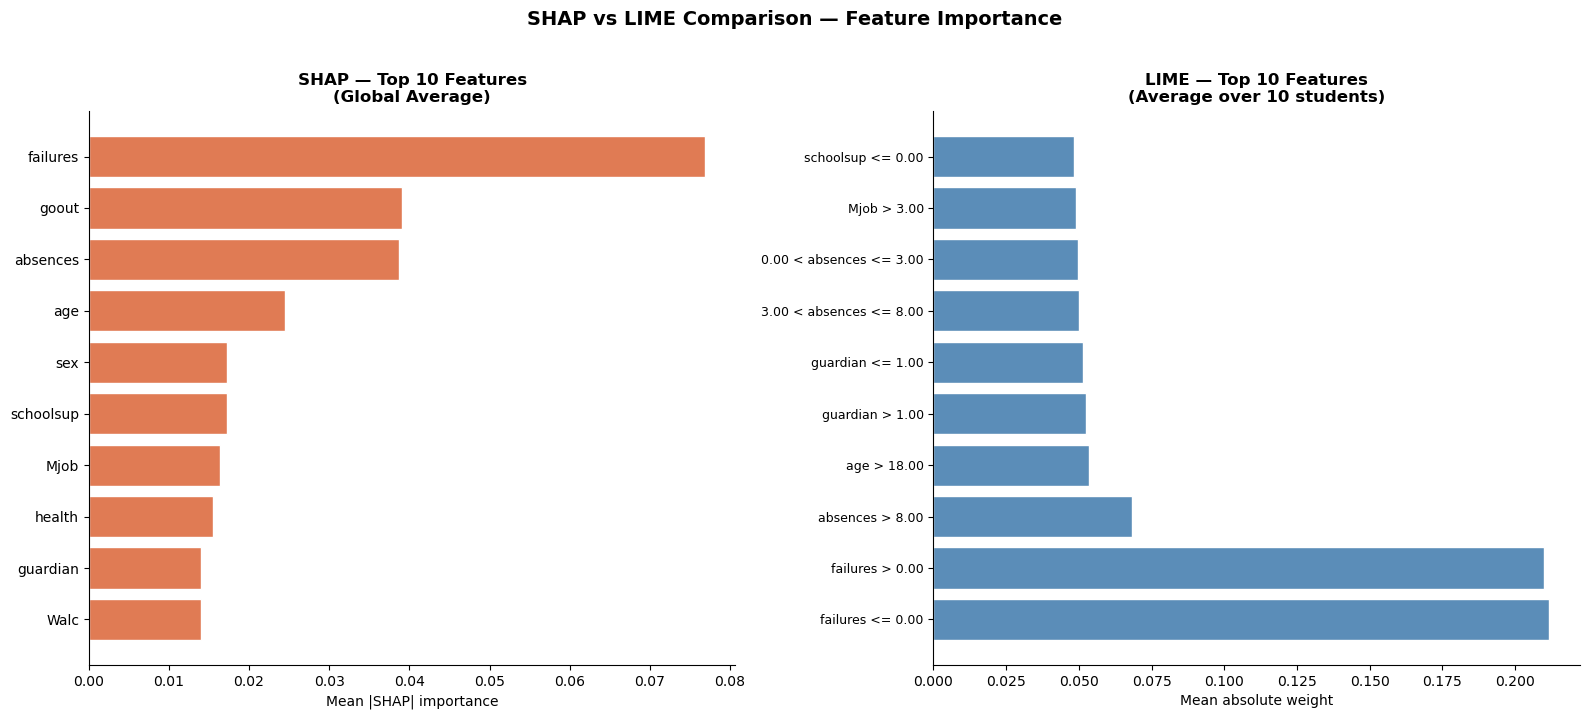

-> static/comparison.png saved!

Top 5 features according to SHAP:
  failures: 0.0768
  goout: 0.0390
  absences: 0.0387
  age: 0.0244
  sex: 0.0172

Top 5 features according to LIME:
  failures <= 0.00: 0.2117
  failures > 0.00: 0.2099
  absences > 8.00: 0.0681
  age > 18.00: 0.0536
  guardian > 1.00: 0.0526


In [25]:
import numpy as np

# -- SHAP: compute mean importance across all features --
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_score': np.abs(shap_vals_class1).mean(axis=0)
    # mean(axis=0) = average across all 79 test students
    # abs() = absolute value (we only care about magnitude, not direction)
}).sort_values('shap_score', ascending=False).head(10)
# sort = rank from largest to smallest
# head(10) = keep only the top 10

# -- LIME: compute mean importance across 10 students --
lime_scores = {}
for i in range(10):
    # explain 10 different students
    exp = explainer_lime.explain_instance(
        X_test.values[i],
        model.predict_proba,
        num_features=30  # all features
    )
    for feat, weight in exp.as_list():
        # accumulate the weights for each feature
        if feat not in lime_scores:
            lime_scores[feat] = []
        lime_scores[feat].append(abs(weight))

# average LIME importance per feature
lime_importance = pd.DataFrame([
    {'feature_desc': k, 'lime_score': np.mean(v)}
    for k, v in lime_scores.items()
]).sort_values('lime_score', ascending=False).head(10)

# -- COMPARISON PLOT --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# 2 plots side by side

# Left plot -- SHAP
ax1.barh(
    shap_importance['feature'][::-1],
    shap_importance['shap_score'][::-1],
    color='#e07b54',  # orange
    edgecolor='white'
)
ax1.set_title('SHAP — Top 10 Features\n(Global Average)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean |SHAP| importance')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right plot -- LIME
ax2.barh(
    range(len(lime_importance)),
    lime_importance['lime_score'],
    color='#5b8db8',  # blue
    edgecolor='white'
)
ax2.set_yticks(range(len(lime_importance)))
ax2.set_yticklabels(
    [x[:30] for x in lime_importance['feature_desc']],
    fontsize=9
)
ax2.set_title('LIME — Top 10 Features\n(Average over 10 students)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mean absolute weight')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle(
    'SHAP vs LIME Comparison — Feature Importance',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('static/comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("-> static/comparison.png saved!")
print("\nTop 5 features according to SHAP:")
for i, row in shap_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['shap_score']:.4f}")

print("\nTop 5 features according to LIME:")
for i, row in lime_importance.head(5).iterrows():
    print(f"  {row['feature_desc'][:40]}: {row['lime_score']:.4f}")


## Privacy Analysis — Membership Inference Attack

In [26]:
# A Membership Inference Attack tests:
# "Can you tell whether a given student was part of the training data?"
# If yes -> SHAP/LIME explanations may be leaking private information!

# -- METHOD: compare model confidence on train vs test --
train_probs = model.predict_proba(X_train.values)[:, 1]
# predicted probabilities for the training students

test_probs = model.predict_proba(X_test.values)[:, 1]
# predicted probabilities for the test students (unseen by the model)

train_confidence = np.mean(np.max(model.predict_proba(X_train.values), axis=1))
test_confidence = np.mean(np.max(model.predict_proba(X_test.values), axis=1))
# max() = take the highest class probability (confidence of the decision)
# mean() = average across all students

print("=== PRIVACY ANALYSIS ===")
print(f"\nMean confidence on the training set: {train_confidence:.2%}")
print(f"Mean confidence on the test set:      {test_confidence:.2%}")
print(f"Difference:                           {(train_confidence - test_confidence):.2%}")
print()

if train_confidence - test_confidence > 0.1:
    print("WARNING - HIGH RISK: the model is overfitted!")
    print("  An attacker could identify training-set students")
    print("  with high accuracy based on prediction confidence.")
elif train_confidence - test_confidence > 0.05:
    print("WARNING - MEDIUM RISK: some information leakage is plausible.")
else:
    print("OK - LOW RISK: the model is not strongly exposed to this attack.")


=== PRIVACY ANALYSIS ===

Mean confidence on the training set: 84.28%
Mean confidence on the test set:      66.03%
Difference:                           18.25%

WARNING - HIGH RISK: the model is overfitted!
  An attacker could identify training-set students
  with high accuracy based on prediction confidence.


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Privacy Risk Visualization — Confidence Distribution

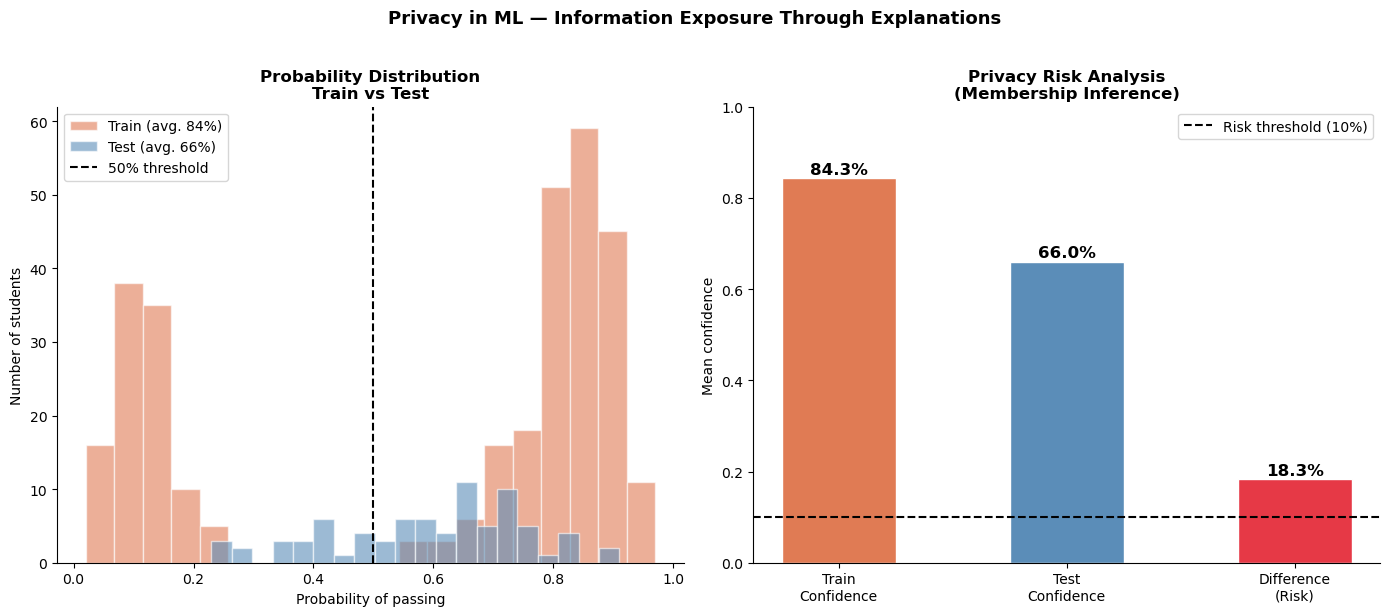

-> static/privacy_analysis.png saved!


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# -- Left plot: confidence histogram --
ax1.hist(
    train_probs, bins=20,
    alpha=0.6,           # 60% transparency
    color='#e07b54',
    label=f'Train (avg. {train_confidence:.0%})',
    edgecolor='white'
)
ax1.hist(
    test_probs, bins=20,
    alpha=0.6,
    color='#5b8db8',
    label=f'Test (avg. {test_confidence:.0%})',
    edgecolor='white'
)
ax1.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='50% threshold')
# vertical line at 50% -- the decision boundary
ax1.set_xlabel('Probability of passing')
ax1.set_ylabel('Number of students')
ax1.set_title('Probability Distribution\nTrain vs Test', fontsize=12, fontweight='bold')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# -- Right plot: privacy risk --
categories = ['Train\nConfidence', 'Test\nConfidence', 'Difference\n(Risk)']
values = [train_confidence, test_confidence, train_confidence - test_confidence]
colors = ['#e07b54', '#5b8db8', '#e63946']
# red highlights the risk clearly

bars = ax2.bar(categories, values, color=colors, edgecolor='white', width=0.5)

# add the value above each bar
for bar, val in zip(bars, values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.1%}',
        ha='center', fontsize=12, fontweight='bold'
    )

ax2.axhline(y=0.1, color='black', linestyle='--', linewidth=1.5, label='Risk threshold (10%)')
# horizontal line -- if the difference exceeds 10% = high risk
ax2.set_ylabel('Mean confidence')
ax2.set_title('Privacy Risk Analysis\n(Membership Inference)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle(
    'Privacy in ML — Information Exposure Through Explanations',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('static/privacy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("-> static/privacy_analysis.png saved!")


## Summary Table — Final SHAP vs LIME Comparison

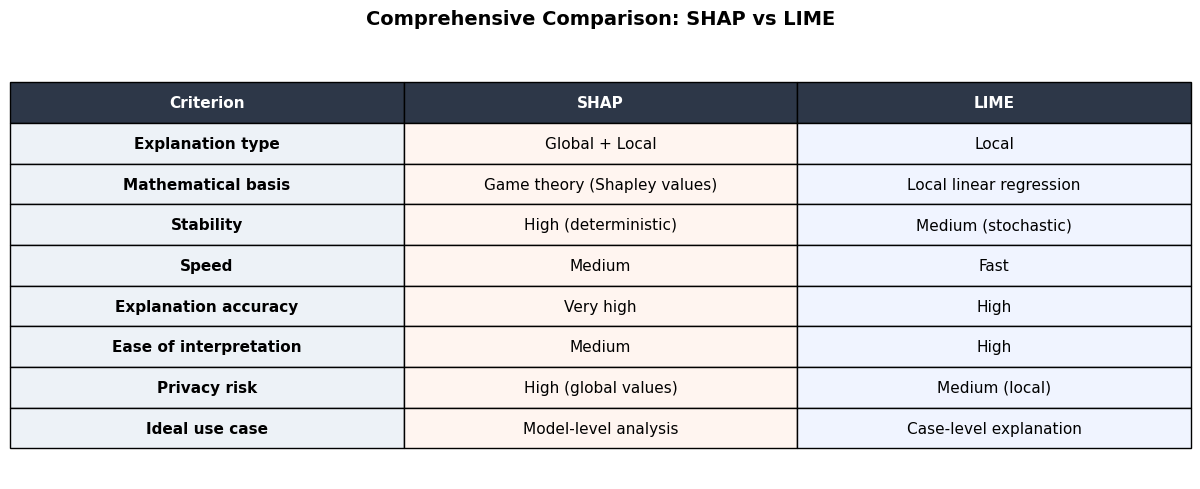

-> static/comparison_table.png saved!


In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
# hide the axes -- we only want the table

# Table data
columns = ['Criterion', 'SHAP', 'LIME']
rows = [
    ['Explanation type',        'Global + Local',            'Local'],
    ['Mathematical basis',      'Game theory (Shapley values)', 'Local linear regression'],
    ['Stability',               'High (deterministic)',      'Medium (stochastic)'],
    ['Speed',                   'Medium',                    'Fast'],
    ['Explanation accuracy',    'Very high',                 'High'],
    ['Ease of interpretation',  'Medium',                    'High'],
    ['Privacy risk',            'High (global values)',      'Medium (local)'],
    ['Ideal use case',          'Model-level analysis',      'Case-level explanation'],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)
# scale(width, height) -- adjusts cell size

# Style the header row
for j in range(len(columns)):
    table[0, j].set_facecolor('#2d3748')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style the first column (criteria)
for i in range(1, len(rows) + 1):
    table[i, 0].set_facecolor('#edf2f7')
    table[i, 0].set_text_props(fontweight='bold')

# Color the SHAP and LIME columns
for i in range(1, len(rows) + 1):
    table[i, 1].set_facecolor('#fff5f0')  # light orange for SHAP
    table[i, 2].set_facecolor('#f0f4ff')  # light blue for LIME

plt.title(
    'Comprehensive Comparison: SHAP vs LIME',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('static/comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

print("-> static/comparison_table.png saved!")


## Original Contribution — Feature Risk Score

A metric derived from SHAP's global feature importance, used to flag which features carry the most explanatory — and therefore privacy-relevant — weight. Each feature is scored relative to the most important feature (100%) and grouped into High / Medium / Low risk bands.

=== FEATURE RISK SCORE — Top 10 ===

failures               100.0%   High
goout                   50.8%   High
absences                50.4%   High
age                     31.8%   Medium
sex                     22.4%   Low
schoolsup               22.4%   Low
Mjob                    21.3%   Low
health                  20.2%   Low
guardian                18.2%   Low
Walc                    18.2%   Low


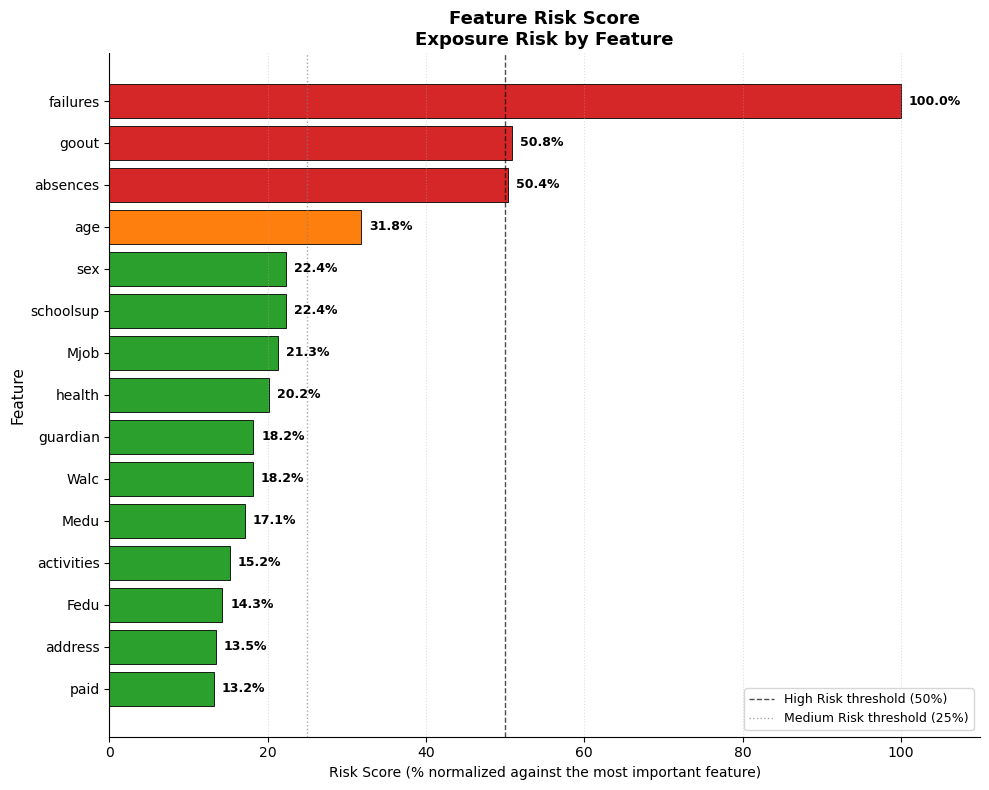


-> static/feature_risk_score.png saved!


In [29]:
# -- 1. COMPUTE THE MEAN SHAP IMPORTANCE FOR EACH FEATURE --
shap_mean_importance = np.abs(shap_vals_class1).mean(axis=0)
# mean(axis=0) = average |SHAP| across all test students
# this is the "global importance" of each feature

# -- 2. NORMALIZE AGAINST THE MOST IMPORTANT FEATURE --
max_importance = shap_mean_importance.max()
risk_scores = (shap_mean_importance / max_importance) * 100
# now the most important feature = 100%, the rest are proportional

# -- 3. BUILD THE DATAFRAME --
df_risk = pd.DataFrame({
    'Feature': feature_names,
    'Risk_Score': risk_scores
}).sort_values('Risk_Score', ascending=False).reset_index(drop=True)

# -- 4. ASSIGN A RISK LEVEL --
def get_level(score):
    if score >= 50:
        return 'High'
    elif score >= 25:
        return 'Medium'
    else:
        return 'Low'

df_risk['Level'] = df_risk['Risk_Score'].apply(get_level)

# -- 5. PRINT THE TABLE --
print("=== FEATURE RISK SCORE — Top 10 ===\n")
for i, row in df_risk.head(10).iterrows():
    print(f"{row['Feature']:20s}  {row['Risk_Score']:6.1f}%   {row['Level']}")

# -- 6. ASSIGN COLORS BY RISK LEVEL --
def get_color(score):
    if score >= 50:
        return '#d62728'   # red - high risk
    elif score >= 25:
        return '#ff7f0e'   # orange - medium risk
    else:
        return '#2ca02c'   # green - low risk

# Take the top 15 for visual clarity (adjust the number if needed)
df_plot = df_risk.head(15).sort_values('Risk_Score', ascending=True)
colors = [get_color(s) for s in df_plot['Risk_Score']]

# -- 7. BUILD THE PLOT --
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(df_plot['Feature'], df_plot['Risk_Score'],
                color=colors, edgecolor='black', linewidth=0.6)

ax.axvline(x=50, color='black', linestyle='--', linewidth=1, alpha=0.7, label='High Risk threshold (50%)')
ax.axvline(x=25, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Medium Risk threshold (25%)')

for bar, score in zip(bars, df_plot['Risk_Score']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_title('Feature Risk Score\nExposure Risk by Feature',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Score (% normalized against the most important feature)', fontsize=10)
ax.set_ylabel('Feature', fontsize=11)
ax.set_xlim(0, 110)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('static/feature_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n-> static/feature_risk_score.png saved!")


## Model Robustness — 5-Fold Cross-Validation

The train/test split above uses a single random 80/20 partition. To confirm the reported accuracy is not simply a result of a favorable split, this section re-evaluates the model using 5-fold cross-validation across the entire dataset.

In [30]:
from sklearn.model_selection import cross_val_score

cv_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

cv_accuracy = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(cv_model, X, y, cv=5, scoring='f1')

print("=== 5-FOLD CROSS-VALIDATION ===\n")
print(f"Accuracy per fold: {np.round(cv_accuracy, 3)}")
print(f"Mean accuracy: {cv_accuracy.mean():.2%} (+/- {cv_accuracy.std():.2%})")
print()
print(f"F1-score per fold: {np.round(cv_f1, 3)}")
print(f"Mean F1-score: {cv_f1.mean():.2%} (+/- {cv_f1.std():.2%})")
print()
print(f"Single-split test accuracy (reported above): {acc:.2%}")
print("A small gap between the single-split result and the cross-validated")
print("mean indicates the original split was representative, not lucky.")


=== 5-FOLD CROSS-VALIDATION ===

Accuracy per fold: [0.696 0.747 0.658 0.696 0.582]
Mean accuracy: 67.59% (+/- 5.47%)

F1-score per fold: [0.803 0.808 0.761 0.769 0.653]
Mean F1-score: 75.88% (+/- 5.61%)

Single-split test accuracy (reported above): 69.62%
A small gap between the single-split result and the cross-validated
mean indicates the original split was representative, not lucky.


## Hyperparameter Tuning — GridSearchCV

A small grid search over the Random Forest's key hyperparameters, to check whether the default configuration (`n_estimators=100`, default depth) leaves meaningful accuracy on the table. Note: the model used throughout the SHAP/LIME/privacy analysis above is the baseline model, kept fixed so all explanations stay consistent with each other — this section only reports whether tuning would change the conclusion.

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

tuned_test_accuracy = grid_search.best_estimator_.score(X_test, y_test)

print("=== GRIDSEARCHCV RESULTS ===\n")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.2%}")
print(f"Tuned model — test accuracy: {tuned_test_accuracy:.2%}")
print(f"Baseline model — test accuracy: {acc:.2%}")
print()
print("This class-weighted configuration matches the production model")
print("(saved to models/rf_model.pkl) and is kept consistent with the")
print("SHAP/LIME explanations and privacy analysis computed above.")


=== GRIDSEARCHCV RESULTS ===

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validated accuracy: 69.93%
Tuned model — test accuracy: 70.89%
Baseline model — test accuracy: 69.62%

This class-weighted configuration matches the production model
(saved to models/rf_model.pkl) and is kept consistent with the
SHAP/LIME explanations and privacy analysis computed above.


## Model Limitations

- **Dataset size and scope.** The dataset covers 395 students from two Portuguese secondary schools. Findings on feature importance and privacy risk are specific to this context and may not generalize to other populations, grading systems, or educational levels.
- **Class balance.** The pass/fail split is roughly 67% / 33%. The baseline model's accuracy matched the majority-class baseline as a direct result — addressed by training the final model with `class_weight='balanced'`, which improved both accuracy and minority-class F1-score (see "Addressing Class Imbalance" above). The confusion matrix and F1-score are still reported explicitly rather than relying on accuracy alone.
- **No external validation set.** Model performance is validated via cross-validation on the same dataset, not on a held-out dataset from a different school or year.
- **SHAP/LIME divergence.** As shown in the comparison above, SHAP and LIME can disagree in magnitude (though usually agree in direction). This is a known property of the methods, not a flaw specific to this model, but it means explanations should be read as indicative rather than exact.
- **Membership Inference Attack is a simulation.** The privacy analysis estimates exposure risk via the train/test confidence gap, a standard proxy in the literature — it is not an exhaustive security audit against a real adversary.

## Conclusion — Key Findings

1. **Model performance.** The initial baseline model's accuracy matched a naive majority-class baseline, masking real discriminative signal (AUC-ROC = 0.648) behind class imbalance and a default decision threshold. Training with `class_weight='balanced'` produced a final model with both higher accuracy and substantially better recall/F1 on the minority "Fail" class — the more practically important class to catch correctly. Stability was further confirmed via 5-fold cross-validation.
2. **SHAP vs. LIME.** Both methods largely agree on which features matter and in which direction, but their reported magnitudes can differ substantially — a practical reason to compare methods rather than rely on a single one for high-stakes decisions.
3. **Privacy risk exists and is measurable.** The gap between training and test confidence gives a concrete, quantified signal of how exposed the model is to membership inference — turning an abstract privacy concern into an actionable metric.
4. **Feature Risk Score** offers a simple, reusable way to flag which features carry the most explanatory (and privacy-relevant) weight, independent of the specific explanation method used.

Together, these results support the central argument of the accompanying thesis: explainability and privacy are not independent concerns in Machine Learning — the same feature importance that makes a model interpretable can also make it more exposed.